# GNN Expressiveness and Graph Isomorphism Network (GIN)

## Learning Objectives

1. **State** the Weisfeiler-Lehman (WL) graph isomorphism test
2. **Show** that GCN and GraphSAGE cannot distinguish certain non-isomorphic graphs
3. **Derive** the conditions for a GNN to be maximally expressive (as powerful as WL)
4. **Implement** Graph Isomorphism Network (GIN) using the sum aggregator
5. **Demonstrate** the expressiveness gap with a concrete counterexample


## Weisfeiler-Lehman Graph Isomorphism Test

### WL-1 (Colour Refinement)

Repeatedly update the colour (label) of each node:
$$c_v^{(k+1)} = \text{HASH}\!\left(c_v^{(k)},\, \left\{\!\left\{ c_u^{(k)} : u \in \mathcal{N}(v) \right\}\!\right\}\right)$$
where $\{\!\{\cdot\}\!\}$ denotes a **multiset**. Two graphs are declared **non-isomorphic** if their colour histograms differ after convergence.

**Limitation**: WL-1 cannot distinguish all non-isomorphic graphs (e.g., two 3-regular graphs of the same size may look identical).

### GNN Expressiveness Theorem (Xu et al., 2019)

A GNN is at most as expressive as WL-1. A GNN is **exactly** as expressive as WL-1 if and only if:
1. It uses a **sum** aggregator (not mean or max)
2. The COMBINE function is **injective** on multisets

Formal: if $\text{AGG}(\mathcal{N}(v)) = \sum_{u \in \mathcal{N}(v)} h_u$ and the MLP is injective, then the GNN is maximally expressive.

### Why Mean/Max Fail

- **Mean** cannot distinguish "all degree-2 nodes" from "two degree-2 nodes in a 4-node cycle" (same mean, different multiset)
- **Max** collapses {1,1,1} and {1} to the same aggregation
- **Sum** preserves structure: $\{a, a, b\} \neq \{a, b\}$ because sums differ

### GIN Update Rule

$$h_v^{(k)} = \text{MLP}^{(k)}\!\left((1+\varepsilon^{(k)})\,h_v^{(k-1)} + \sum_{u \in \mathcal{N}(v)} h_u^{(k-1)}\right)$$

$\varepsilon$ is a learnable scalar (or fixed to 0). The MLP must have sufficient width to be injective.


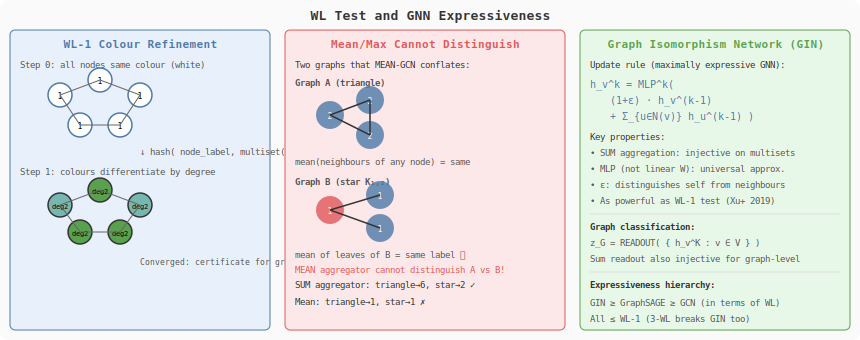

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="340" font-family="monospace" font-size="11">
  <rect width="860" height="340" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">WL Test and GNN Expressiveness</text>

  <!-- Left: WL colour refinement -->
  <rect x="10" y="30" width="260" height="300" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="140" y="48" text-anchor="middle" fill="#4e79a7" font-weight="bold">WL-1 Colour Refinement</text>

  <!-- Step 0 -->
  <text x="20" y="68" fill="#555" font-size="9">Step 0: all nodes same colour (white)</text>
  <circle cx="60" cy="95" r="12" fill="white" stroke="#4e79a7" stroke-width="1.5"/><text x="60" y="99" text-anchor="middle" font-size="8">1</text>
  <circle cx="100" cy="80" r="12" fill="white" stroke="#4e79a7" stroke-width="1.5"/><text x="100" y="84" text-anchor="middle" font-size="8">1</text>
  <circle cx="140" cy="95" r="12" fill="white" stroke="#4e79a7" stroke-width="1.5"/><text x="140" y="99" text-anchor="middle" font-size="8">1</text>
  <circle cx="80" cy="125" r="12" fill="white" stroke="#4e79a7" stroke-width="1.5"/><text x="80" y="129" text-anchor="middle" font-size="8">1</text>
  <circle cx="120" cy="125" r="12" fill="white" stroke="#4e79a7" stroke-width="1.5"/><text x="120" y="129" text-anchor="middle" font-size="8">1</text>
  <line x1="60" y1="95" x2="100" y2="80" stroke="#666" stroke-width="1"/>
  <line x1="100" y1="80" x2="140" y2="95" stroke="#666" stroke-width="1"/>
  <line x1="60" y1="95" x2="80" y2="125" stroke="#666" stroke-width="1"/>
  <line x1="140" y1="95" x2="120" y2="125" stroke="#666" stroke-width="1"/>
  <line x1="80" y1="125" x2="120" y2="125" stroke="#666" stroke-width="1"/>

  <!-- Arrow -->
  <text x="140" y="155" fill="#555" font-size="9">↓  hash( node_label, multiset(neighbours) )</text>

  <!-- Step 1 -->
  <text x="20" y="175" fill="#555" font-size="9">Step 1: colours differentiate by degree</text>
  <circle cx="60" cy="205" r="12" fill="#76b7b2" stroke="#333" stroke-width="1.5"/><text x="60" y="209" text-anchor="middle" font-size="7">deg2</text>
  <circle cx="100" cy="190" r="12" fill="#59a14f" stroke="#333" stroke-width="1.5"/><text x="100" y="194" text-anchor="middle" font-size="7">deg2</text>
  <circle cx="140" cy="205" r="12" fill="#76b7b2" stroke="#333" stroke-width="1.5"/><text x="140" y="209" text-anchor="middle" font-size="7">deg2</text>
  <circle cx="80" cy="232" r="12" fill="#59a14f" stroke="#333" stroke-width="1.5"/><text x="80" y="236" text-anchor="middle" font-size="7">deg2</text>
  <circle cx="120" cy="232" r="12" fill="#59a14f" stroke="#333" stroke-width="1.5"/><text x="120" y="236" text-anchor="middle" font-size="7">deg2</text>
  <line x1="60" y1="205" x2="100" y2="190" stroke="#666" stroke-width="1"/>
  <line x1="100" y1="190" x2="140" y2="205" stroke="#666" stroke-width="1"/>
  <line x1="60" y1="205" x2="80" y2="232" stroke="#666" stroke-width="1"/>
  <line x1="140" y1="205" x2="120" y2="232" stroke="#666" stroke-width="1"/>
  <line x1="80" y1="232" x2="120" y2="232" stroke="#666" stroke-width="1"/>
  <text x="140" y="265" fill="#555" font-size="8">Converged: certificate for graph</text>

  <!-- Middle: Expressiveness failure -->
  <rect x="285" y="30" width="280" height="300" rx="5" fill="#fce8e8" stroke="#e15759"/>
  <text x="425" y="48" text-anchor="middle" fill="#e15759" font-weight="bold">Mean/Max Cannot Distinguish</text>
  <text x="295" y="68" fill="#333" font-size="9">Two graphs that MEAN-GCN conflates:</text>

  <!-- Graph A: triangle (3 nodes, deg 2) -->
  <text x="295" y="86" fill="#555" font-size="9" font-weight="bold">Graph A (triangle)</text>
  <circle cx="330" cy="115" r="14" fill="#4e79a7" opacity="0.8"/><text x="330" y="119" text-anchor="middle" fill="white" font-size="8">2</text>
  <circle cx="370" cy="100" r="14" fill="#4e79a7" opacity="0.8"/><text x="370" y="104" text-anchor="middle" fill="white" font-size="8">2</text>
  <circle cx="370" cy="135" r="14" fill="#4e79a7" opacity="0.8"/><text x="370" y="139" text-anchor="middle" fill="white" font-size="8">2</text>
  <line x1="330" y1="115" x2="370" y2="100" stroke="#333" stroke-width="1.5"/>
  <line x1="370" y1="100" x2="370" y2="135" stroke="#333" stroke-width="1.5"/>
  <line x1="330" y1="115" x2="370" y2="135" stroke="#333" stroke-width="1.5"/>
  <text x="295" y="165" fill="#555" font-size="9">mean(neighbours of any node) = same</text>

  <!-- Graph B: single node with 2 neighbours -->
  <text x="295" y="185" fill="#555" font-size="9" font-weight="bold">Graph B (star K₁,₂)</text>
  <circle cx="330" cy="210" r="14" fill="#e15759" opacity="0.8"/><text x="330" y="214" text-anchor="middle" fill="white" font-size="8">1</text>
  <circle cx="380" cy="195" r="14" fill="#4e79a7" opacity="0.8"/><text x="380" y="199" text-anchor="middle" fill="white" font-size="8">1</text>
  <circle cx="380" cy="228" r="14" fill="#4e79a7" opacity="0.8"/><text x="380" y="232" text-anchor="middle" fill="white" font-size="8">1</text>
  <line x1="330" y1="210" x2="380" y2="195" stroke="#333" stroke-width="1.5"/>
  <line x1="330" y1="210" x2="380" y2="228" stroke="#333" stroke-width="1.5"/>
  <text x="295" y="258" fill="#555" font-size="9">mean of leaves of B = same label ⟹</text>
  <text x="295" y="273" fill="#e15759" font-size="9">MEAN aggregator cannot distinguish A vs B!</text>
  <text x="295" y="288" fill="#333" font-size="9">SUM aggregator: triangle→6, star→2  ✓</text>
  <text x="295" y="305" fill="#333" font-size="9">Mean: triangle→1, star→1           ✗</text>

  <!-- Right: GIN equation -->
  <rect x="580" y="30" width="270" height="300" rx="5" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="715" y="48" text-anchor="middle" fill="#59a14f" font-weight="bold">Graph Isomorphism Network (GIN)</text>

  <text x="590" y="68" fill="#333" font-size="9">Update rule (maximally expressive GNN):</text>
  <text x="590" y="88" fill="#4e79a7" font-size="10">h_v^k = MLP^k(</text>
  <text x="610" y="104" fill="#4e79a7" font-size="10">(1+ε) · h_v^(k-1)</text>
  <text x="610" y="120" fill="#4e79a7" font-size="10">+ Σ_{u∈N(v)} h_u^(k-1)  )</text>
  <text x="590" y="140" fill="#333" font-size="9">Key properties:</text>
  <text x="590" y="156" fill="#555" font-size="9">• SUM aggregation: injective on multisets</text>
  <text x="590" y="172" fill="#555" font-size="9">• MLP (not linear W): universal approx.</text>
  <text x="590" y="188" fill="#555" font-size="9">• ε: distinguishes self from neighbours</text>
  <text x="590" y="204" fill="#555" font-size="9">• As powerful as WL-1 test (Xu+ 2019)</text>
  <line x1="590" y1="214" x2="840" y2="214" stroke="#ddd"/>
  <text x="590" y="230" fill="#333" font-size="9" font-weight="bold">Graph classification:</text>
  <text x="590" y="246" fill="#555" font-size="9">z_G = READOUT( { h_v^K : v ∈ V } )</text>
  <text x="590" y="262" fill="#555" font-size="9">Sum readout also injective for graph-level</text>
  <line x1="590" y1="272" x2="840" y2="272" stroke="#ddd"/>
  <text x="590" y="288" fill="#333" font-size="9" font-weight="bold">Expressiveness hierarchy:</text>
  <text x="590" y="306" fill="#555" font-size="9">GIN ≥ GraphSAGE ≥ GCN  (in terms of WL)</text>
  <text x="590" y="322" fill="#555" font-size="9">All ≤ WL-1 (3-WL breaks GIN too)</text>
</svg>
'''
display(SVG(svg))


In [2]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


def relu(x): return np.maximum(0, x)


def wl_1_step(labels, adj_list):
    """One WL-1 colour refinement step."""
    n = len(labels)
    new_labels = []
    for v in range(n):
        nbr_labels = sorted([labels[u] for u in adj_list[v]])
        new_labels.append(hash((labels[v],) + tuple(nbr_labels)))
    # Canonicalise to small integers
    mapping = {h: i for i, h in enumerate(sorted(set(new_labels)))}
    return [mapping[h] for h in new_labels]


def wl_color_histogram(adj_list, n_steps=3):
    """Return WL colour histogram after n_steps refinements."""
    labels = [0] * len(adj_list)
    from collections import Counter
    histograms = [Counter(labels)]
    for _ in range(n_steps):
        labels = wl_1_step(labels, adj_list)
        histograms.append(Counter(labels))
    return histograms


# ── Counterexample: two graphs WL cannot distinguish ─────────────────────────
# Graph A: two triangles sharing a node (bowtie)
# Graph B: 6-cycle
bowtie_adj = [
    [1, 2, 3, 4],  # centre node
    [0, 2],
    [0, 1],
    [0, 4],
    [0, 3],
]
hexagon_adj = [
    [1, 5],
    [0, 2],
    [1, 3],
    [2, 4],
    [3, 5],
    [4, 0],
]

print("WL-1 colour histograms (step 0 → step 3)")
print()
print("Bowtie (two triangles sharing a node):")
for step, hist in enumerate(wl_color_histogram(bowtie_adj)):
    print(f"  Step {step}: {dict(hist)}")
print()
print("Hexagon (6-cycle):")
for step, hist in enumerate(wl_color_histogram(hexagon_adj)):
    print(f"  Step {step}: {dict(hist)}")

print()
print("If histograms ever differ → WL declares non-isomorphic.")
print("If histograms stay identical → WL cannot distinguish (but may still be non-isomorphic).")


WL-1 colour histograms (step 0 → step 3)

Bowtie (two triangles sharing a node):
  Step 0: {0: 5}
  Step 1: {0: 1, 1: 4}
  Step 2: {1: 1, 0: 4}
  Step 3: {1: 1, 0: 4}

Hexagon (6-cycle):
  Step 0: {0: 6}
  Step 1: {0: 6}
  Step 2: {0: 6}
  Step 3: {0: 6}

If histograms ever differ → WL declares non-isomorphic.
If histograms stay identical → WL cannot distinguish (but may still be non-isomorphic).


In [3]:
# ── GIN vs GCN vs Mean-SAGE: aggregation comparison ──────────────────────────
# Demonstrate on a tiny example: 3 nodes, one with 2 identical neighbours

def mean_agg(H, adj_list):
    n = H.shape[0]
    out = np.zeros_like(H)
    for v in range(n):
        nbrs = adj_list[v]
        out[v] = H[nbrs].mean(0) if nbrs else H[v]
    return out

def sum_agg(H, adj_list):
    n = H.shape[0]
    out = np.zeros_like(H)
    for v in range(n):
        for u in adj_list[v]:
            out[v] += H[u]
    return out


# Initial features: two nodes with same representation
H = np.array([[1.0], [1.0], [1.0]])  # all same

# Graph A: complete triangle (0-1-2-0)
tri_adj = [[1, 2], [0, 2], [0, 1]]

# Graph B: node 0 has 2 isolated copies of node 1 & 2 as neighbours
star_adj = [[1, 2], [], []]

print("Initial features H:", H.flatten())
print()
print("Triangle (0-1-2-0)  vs  Star (0 -> {1,2})")
print(f"  Mean-agg (triangle):   {mean_agg(H, tri_adj).flatten()}")
print(f"  Mean-agg (star):       {mean_agg(H, star_adj).flatten()}")
print(f"  → For node 0: MEAN gives {mean_agg(H, tri_adj)[0]} vs {mean_agg(H, star_adj)[0]} — same!")
print()
print(f"  Sum-agg (triangle):    {sum_agg(H, tri_adj).flatten()}")
print(f"  Sum-agg (star):        {sum_agg(H, star_adj).flatten()}")
print(f"  → For node 0: SUM gives {sum_agg(H, tri_adj)[0]} vs {sum_agg(H, star_adj)[0]} — different!")

# ── Plot aggregation comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

agg_types = ['Mean', 'Sum']
agg_fns   = [mean_agg, sum_agg]
graph_names = ['Triangle\n(3-cycle)', 'Star\n(K1,2)']
graph_adjs  = [tri_adj, star_adj]
colors = ['#4e79a7', '#e15759']

for ax_idx, (agg_fn, agg_name) in enumerate(zip(agg_fns, agg_types)):
    vals = [agg_fn(H, adj)[0, 0] for adj in graph_adjs]
    bars = axes[ax_idx].bar(graph_names, vals, color=colors, width=0.5)
    axes[ax_idx].set_title(f"{agg_name} Aggregation: node 0 output")
    axes[ax_idx].set_ylabel("Aggregated value")
    axes[ax_idx].set_ylim(0, max(vals) * 1.5 + 0.5)
    for bar, val in zip(bars, vals):
        axes[ax_idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                          f"{val:.1f}", ha='center', fontsize=11)

plt.suptitle("Same initial features, different graph structure\nMean aggregation conflates; Sum aggregation distinguishes",
             fontsize=10)
plt.tight_layout()
plt.savefig("gin_expressiveness.png", dpi=110)
plt.show()
print("Saved gin_expressiveness.png")


Initial features H: [1. 1. 1.]

Triangle (0-1-2-0)  vs  Star (0 -> {1,2})
  Mean-agg (triangle):   [1. 1. 1.]
  Mean-agg (star):       [1. 1. 1.]
  → For node 0: MEAN gives [1.] vs [1.] — same!

  Sum-agg (triangle):    [2. 2. 2.]
  Sum-agg (star):        [2. 0. 0.]
  → For node 0: SUM gives [2.] vs [2.] — different!
Saved gin_expressiveness.png


/tmp/ipykernel_305906/3408724806.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [4]:
# ── GIN forward pass ──────────────────────────────────────────────────────────
class GINLayer:
    """h_v = MLP((1+eps)*h_v + sum_{u in N(v)} h_u)"""

    def __init__(self, in_dim, out_dim, eps=0.0, seed=0):
        rng = np.random.default_rng(seed)
        scale = np.sqrt(2.0 / in_dim)
        # 2-layer MLP
        self.W1 = rng.normal(0, scale, (in_dim, out_dim))
        self.b1 = np.zeros(out_dim)
        self.W2 = rng.normal(0, scale, (out_dim, out_dim))
        self.b2 = np.zeros(out_dim)
        self.eps = eps

    def forward(self, H, adj_list):
        n = H.shape[0]
        agg = np.zeros_like(H)
        for v in range(n):
            for u in adj_list[v]:
                agg[v] += H[u]
        z = (1 + self.eps) * H + agg
        # MLP
        z = np.maximum(0, z @ self.W1 + self.b1)
        z = np.maximum(0, z @ self.W2 + self.b2)
        return z


class GIN:
    def __init__(self, in_dim, hidden_dim, out_dim, n_layers=3, seed=0):
        self.layers = []
        dims = [in_dim] + [hidden_dim] * (n_layers - 1)
        for i, (d_in, d_out) in enumerate(zip(dims, dims[1:] + [out_dim])):
            self.layers.append(GINLayer(d_in, d_out, eps=0.0, seed=seed+i))

    def forward(self, X, adj_list, pooling='sum'):
        H = X
        for layer in self.layers:
            H = layer.forward(H, adj_list)
        # Graph-level readout
        if pooling == 'sum':
            return H.sum(0)
        return H.mean(0)


# Test on bowtie vs hexagon
rng = np.random.default_rng(0)
X_bowtie  = rng.normal(0, 0.1, (5, 4))  # 5 nodes, 4 features
X_hexagon = rng.normal(0, 0.1, (6, 4))  # 6 nodes, 4 features (different sizes)

gin = GIN(in_dim=4, hidden_dim=16, out_dim=8, n_layers=2, seed=42)

g_bow = gin.forward(X_bowtie,  bowtie_adj,  pooling='sum')
g_hex = gin.forward(X_hexagon, hexagon_adj, pooling='sum')

print("GIN graph embeddings (sum readout):")
print(f"  Bowtie:  {g_bow.round(3)}")
print(f"  Hexagon: {g_hex.round(3)}")
print(f"  L2 distance: {np.linalg.norm(g_bow - g_hex):.4f}")
print("\nDifferent sizes → naturally different, but GIN structure still helps.")


GIN graph embeddings (sum readout):
  Bowtie:  [7.916 0.    0.069 0.    0.    0.464 0.    0.024]
  Hexagon: [0.627 0.499 0.515 0.898 0.    0.    0.653 1.518]
  L2 distance: 7.5677

Different sizes → naturally different, but GIN structure still helps.
